# Transformer Autoencoder for Cassini CDA Mass Spectra

This notebook implements a **Transformer Autoencoder** to analyze mass spectra from the Cassini Cosmic Dust Analyzer (CDA).

### Why Transformer Autoencoder?
The Denoising CNN Autoencoder achieved high F1-scores (0.86) but struggled with SNR for chemical peaks, suggesting it's a good feature extractor but poor reconstructor. Transformers with **self-attention mechanisms** can:

1. **Global Context**: Attention heads can focus on sparse chemical peaks across the entire 1000-bin spectrum simultaneously
2. **Peak Preservation**: Multi-head attention can learn to preserve sharp spectral features better than CNNs
3. **Position Awareness**: Positional encodings encode m/z locations explicitly
4. **Long-Range Dependencies**: Can capture relationships between distant peaks (e.g., isotope patterns)

### Architecture Highlights:
- **Embedding Layer**: Projects 1D spectrum bins into d_model dimensional space (128 or 256)
- **Positional Encoding**: Sinusoidal encodings for m/z position awareness
- **Transformer Encoder**: 4-6 layers with 8 attention heads for global peak attention
- **Bottleneck**: Global Average Pooling → compact latent representation
- **Decoder**: Transformer decoder layers + upsampling to original dimension
- **Loss Function**: Intensity-weighted MSE + L1 sparsity penalty

### Expected Improvements:
- **Higher SNR for chemical classes** (3-Na, 3-K, 5-Na) vs CNN approach
- **Lower SNR for Noise class** (correctly suppressing background)
- **Better peak reconstruction** while maintaining high F1-scores

### Pipeline Steps:
1. **Data Loading**: Load Parquet files containing the spectra
2. **Preprocessing**: Savitzky-Golay filtering → log transformation → normalization
3. **Model Architecture**: Transformer Autoencoder with attention mechanism
4. **Training**: Intensity-weighted loss + sparsity constraint
5. **Evaluation**: SNR analysis, Silhouette score, Linear Probe F1

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN, KMeans
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import math

# Configuration
Input_Length = 1000  # Number of bins to resample spectra to
Batch_Size = 32  # Reduced for memory efficiency
Learning_Rate = 1e-4  # Lower learning rate for Transformer
Epochs = 30  # More epochs for Transformer convergence
Latent_Dim = 128  # Dimension of latent bottleneck

# Transformer-specific hyperparameters (MEMORY OPTIMIZED)
D_Model = 128  # Embedding dimension (reduced from 256)
N_Heads = 4  # Number of attention heads (reduced from 8)
N_Encoder_Layers = 4  # Number of Transformer encoder layers (reduced from 6)
N_Decoder_Layers = 2  # Number of Transformer decoder layers (reduced from 4)
Dim_Feedforward = 512  # Dimension of feedforward network (reduced from 1024)
Dropout = 0.1  # Dropout rate

# Training configuration
Intensity_Weight_Power = 2.0  # Power for intensity weighting
L1_Lambda = 1e-4  # L1 penalty weight for latent sparsity
Use_Class_Balanced_Sampling = True  # Enable class-balanced sampling

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Memory Optimization Settings
import gc

# Clear any existing GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Enable memory efficient settings
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print("✓ Memory optimization enabled")

✓ Memory optimization enabled


### 1. Data Loading
We load the data from a Parquet file. This efficient columnar format allows us to handle large datasets of spectra quickly. We also filter or crop the data to ensure we are only training on valid signals.

### 1.1 Class Analysis
Before training, it is crucial to understand the class imbalance. Real-world space data is dominated by "Noise" or empty impacts. Knowing the distribution helps us interpret why the model might cluster certain things together (e.g., if 90% of data is noise, the model will prioritize learning the shape of noise).

In [3]:
# 1. Load Data
# Adjust the filename as needed based on which file you want to train on
file_path = 'cda_qm_spectra_pre2008277_train_lvl2.parquet'

try:
    df = pd.read_parquet(file_path)
    print(f"Loaded data shape: {df.shape}")
    print(df.head())
    
    # Extract spectral data
    # Based on the output, the column is named 'spectrum'
    if 'spectrum' in df.columns:
        print("Found 'spectrum' column.")
        # Ensure it's a stack of numpy arrays
        spectra_raw = np.stack(df['spectrum'].values)
    else:
        raise ValueError(f"Column 'spectrum' not found. Available columns: {df.columns}")

except Exception as e:
    print(f"Error loading data: {e}")
    raise e

Loaded data shape: (19820, 6)
           sclk   f_desc  event_id  \
0  1.477582e+09  6405615      4035   
1  1.477619e+09  6405615      6860   
2  1.477626e+09  6405615     10363   
3  1.477630e+09  6405615     12290   
4  1.477666e+09  6405615     16489   

                                            spectrum       qi_ampl  class  
0  [-6.986339e-07, 0.0, 0.0, -8.7329244e-07, 5.23...  5.004700e-14  Noise  
1  [-1.7465848e-07, -8.7329244e-07, -1.7465848e-0...  4.182420e-14  3-Car  
2  [-1.7465848e-07, -1.7465848e-07, -1.7465848e-0...  1.700580e-14  3-Car  
3  [-3.4931696e-07, -3.4931696e-07, -3.4931696e-0...  1.312510e-14  3-KNa  
4  [-6.986339e-07, 0.0, -3.4931696e-07, -5.239755...  4.949150e-12  Noise  
Found 'spectrum' column.


Class distribution:
class
Noise    12077
1         4491
2         1015
3          909
?          553
4          263
5          186
3-Car       89
3-Cl        47
3-OH        47
3-KNa       41
5-Na        41
3-P         34
3-K         22
2-X          3
X            2
Name: count, dtype: int64

Total number of classes: 16


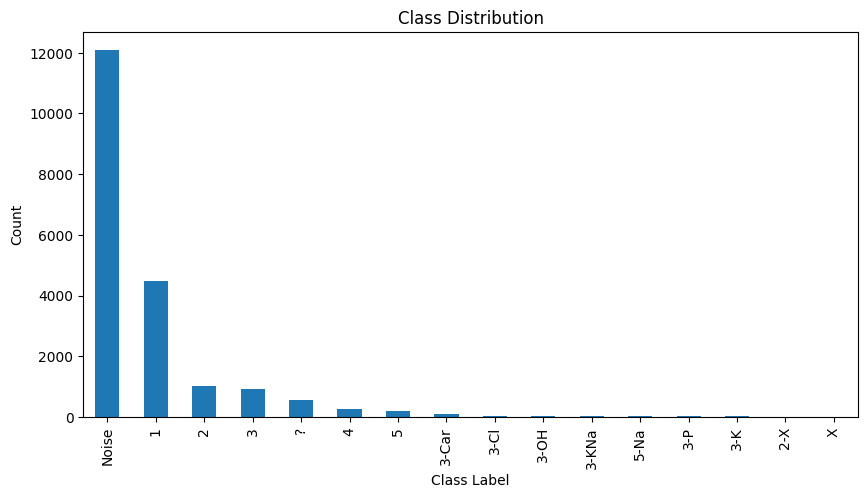

In [4]:
# 1.1 Analyze Classes
if 'class' in df.columns:
    print("Class distribution:")
    class_counts = df['class'].value_counts()
    print(class_counts)
    print(f"\nTotal number of classes: {len(class_counts)}")
    
    # Optional: Plot class distribution
    plt.figure(figsize=(10, 5))
    class_counts.plot(kind='bar')
    plt.title("Class Distribution")
    plt.ylabel("Count")
    plt.xlabel("Class Label")
    plt.show()
else:
    print("Column 'class' not found in dataframe.")

### 2. Preprocessing
We define a function to normalize and reshape the spectra.
*   **Target Length:** 1000 bins. This reduces the input dimensionality while preserving the resolution needed to distinguish mass lines.
*   **Denoising:** Apply Savitzky-Golay filter to smooth out high-frequency noise while preserving peak shapes. This is crucial for mass spectra where sharp peaks contain the chemical information.
*   **Log1p:** $\log(1+x)$ is used to squash the counts. Without this, a single giant peak (e.g., Amplitude 10,000) would render a small but chemically significant peak (Amplitude 10) invisible to the network (it would look like 0.001 after normalization).
*   **Normalization:** Scale to 0-1 range for stable neural network training.

Preprocessing data...
Processed Data Shape: (19820, 1000)

Class Distribution:
  Chemical samples: 7743
  Noise samples: 12077

✓ Class-balanced sampling enabled
  Chemical weight: 0.0001
  Noise weight: 0.0001
DataLoader created.
PREPROCESSING VISUALIZATION
  Key transformations:
    1. Crop/Pad → Fixed 1000-bin length
    2. Savitzky-Golay → Noise reduction while preserving peaks
    3. Log1p → Compress dynamic range (handle large/small peaks)
    4. Normalization → Scale to [0,1] for stable training

Processed Data Shape: (19820, 1000)

Class Distribution:
  Chemical samples: 7743
  Noise samples: 12077

✓ Class-balanced sampling enabled
  Chemical weight: 0.0001
  Noise weight: 0.0001
DataLoader created.
PREPROCESSING VISUALIZATION
  Key transformations:
    1. Crop/Pad → Fixed 1000-bin length
    2. Savitzky-Golay → Noise reduction while preserving peaks
    3. Log1p → Compress dynamic range (handle large/small peaks)
    4. Normalization → Scale to [0,1] for stable training



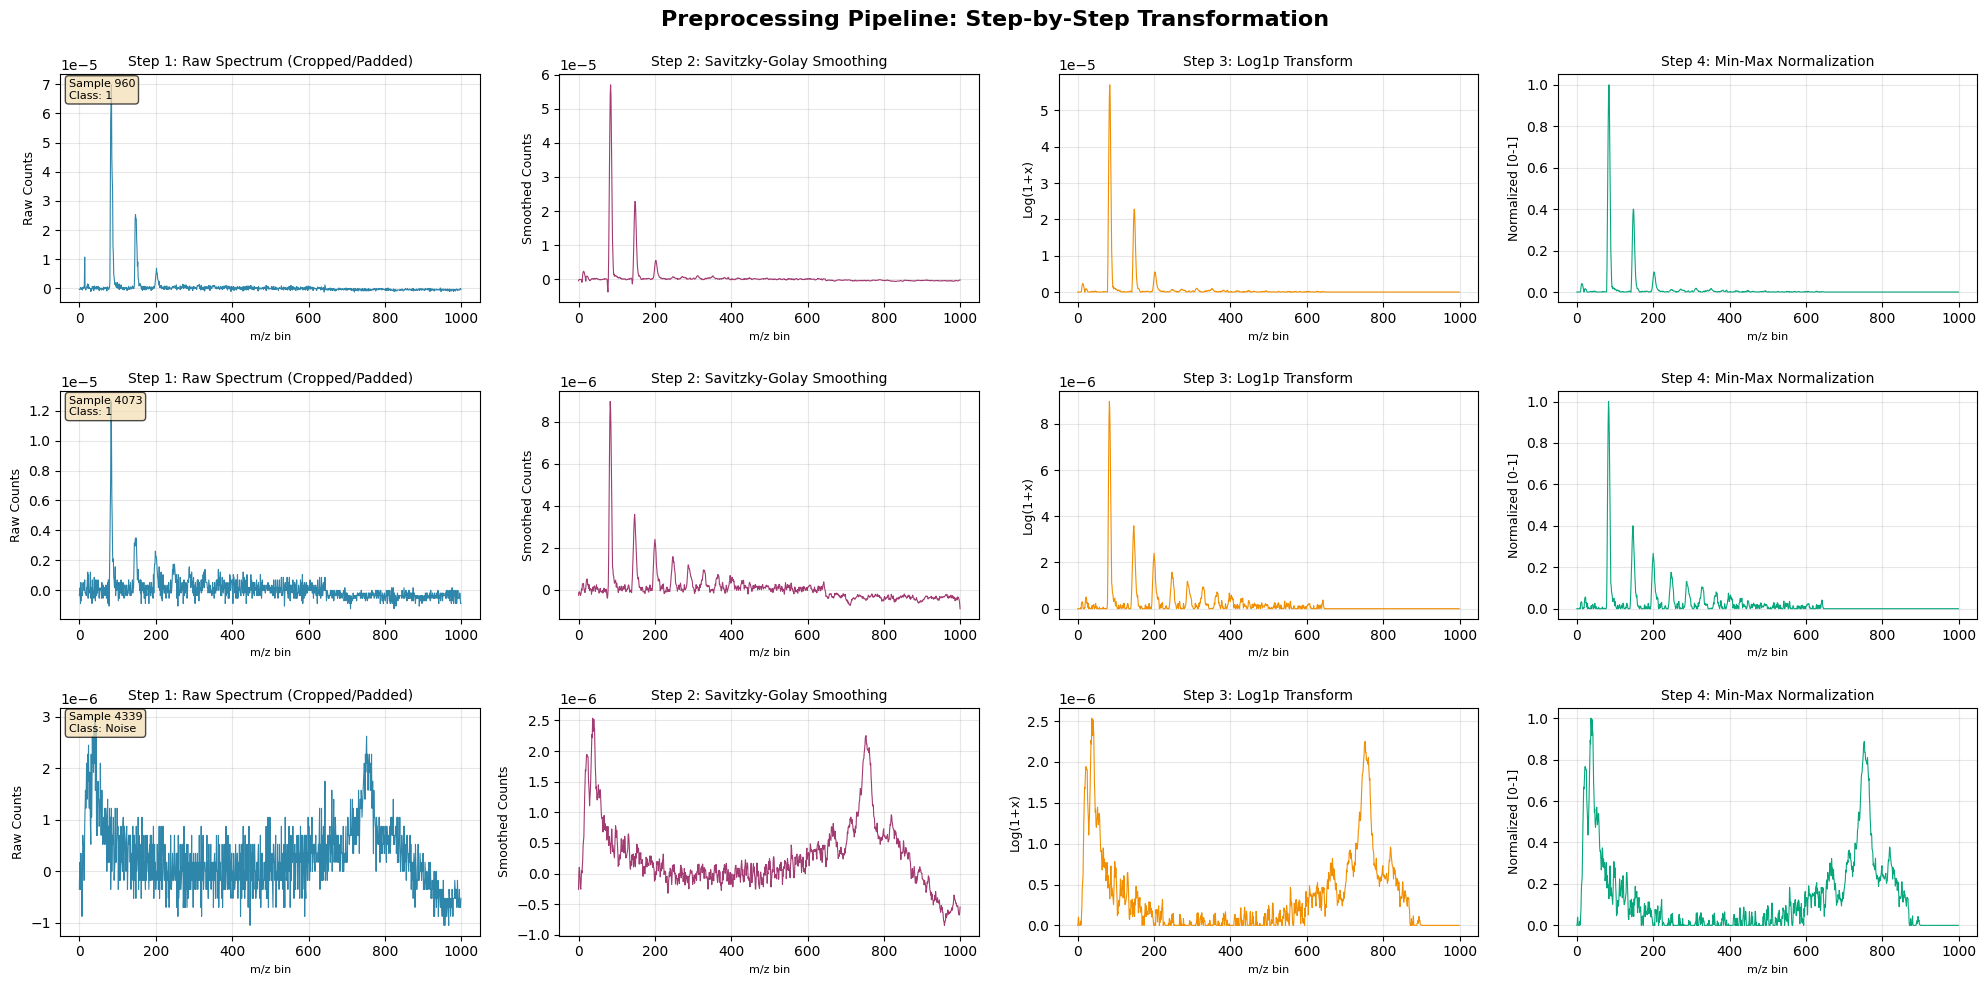


✓ Preprocessing visualization complete


In [5]:
# 2. Preprocessing Function
def preprocess_spectra(spectra, target_length=1000):
    processed = []
    
    for spec in spectra:
        # A. Handling varying lengths (if raw data is list of arrays)
        # Resize or pad/crop to target_length
        if len(spec) >= target_length:
            s = spec[:target_length]
        else:
            s = np.pad(spec, (0, target_length - len(spec)), 'constant')
        
        # B. Denoising with Savitzky-Golay filter
        # This smooths high-frequency noise while preserving peak shapes
        # window_length must be odd and less than array length
        window_length = min(11, len(s) if len(s) % 2 == 1 else len(s) - 1)
        if window_length >= 5:  # Only apply if window is large enough
            s = savgol_filter(s, window_length=window_length, polyorder=3)
        
        # C. Log Transformation (Compress dynamic range)
        # Adding a small epsilon or 1 to avoid log(0) or log(negative) issues if any
        # Assuming minimal value is 0 or -small noise
        s = np.log1p(np.maximum(s, 0))
        
        # D. Max Normalization (Scale to 0-1 range)
        max_val = np.max(s)
        if max_val > 0:
            s = s / max_val
            
        processed.append(s)
        
    return np.array(processed, dtype=np.float32)

# Apply preprocessing
print("Preprocessing data...")
X_train = preprocess_spectra(spectra_raw, target_length=Input_Length)

print(f"Processed Data Shape: {X_train.shape}")

# Convert to PyTorch Tensor
# Add channel dimension: (N, Channels, Length) -> (N, 1, 1000)
X_train_tensor = torch.from_numpy(X_train).unsqueeze(1)

# Create class labels tensor for class-balanced sampling
if 'class' in df.columns:
    class_labels = df['class'].values
    # Define 'Noise' vs 'Chemical' binary classification
    is_noise = np.array(['noise' in str(c).lower() for c in class_labels])
    class_binary = is_noise.astype(int)  # 0 = Chemical, 1 = Noise
    
    print(f"\nClass Distribution:")
    print(f"  Chemical samples: {(class_binary == 0).sum()}")
    print(f"  Noise samples: {(class_binary == 1).sum()}")
    
    # Create dataset with labels for weighted sampling
    dataset = TensorDataset(X_train_tensor, torch.from_numpy(class_binary))
    
    # Setup class-balanced weighted sampler
    if Use_Class_Balanced_Sampling:
        # Calculate inverse class frequencies as weights
        class_counts = np.bincount(class_binary)
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[class_binary]
        
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        
        loader = DataLoader(dataset, batch_size=Batch_Size, sampler=sampler)
        print(f"\n✓ Class-balanced sampling enabled")
        print(f"  Chemical weight: {class_weights[0]:.4f}")
        print(f"  Noise weight: {class_weights[1]:.4f}")
    else:
        loader = DataLoader(dataset, batch_size=Batch_Size, shuffle=True)
        print("\n⚠ Class-balanced sampling disabled (using random shuffle)")
else:
    # Fallback: no class labels available
    dataset = TensorDataset(X_train_tensor)
    loader = DataLoader(dataset, batch_size=Batch_Size, shuffle=True)
    print("\n⚠ No 'class' column found. Using standard random sampling.")

print("DataLoader created.")

# Visualize preprocessing effects
print("="*70)
print("PREPROCESSING VISUALIZATION")
print("="*70)
print("  Key transformations:")
print("    1. Crop/Pad → Fixed 1000-bin length")
print("    2. Savitzky-Golay → Noise reduction while preserving peaks")
print("    3. Log1p → Compress dynamic range (handle large/small peaks)")
print("    4. Normalization → Scale to [0,1] for stable training")
print("\n" + "="*70)

# Select 3 random samples to visualize
np.random.seed(42)
sample_indices = np.random.choice(len(spectra_raw), size=3, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
fig.suptitle('Preprocessing Pipeline: Step-by-Step Transformation', fontsize=16, fontweight='bold')

for ax in axes.flat:
    ax.set_xlabel('m/z bin', fontsize=8)

for i, idx in enumerate(sample_indices):
    spec = spectra_raw[idx]
    
    # Add sample info
    class_label = df.iloc[idx]['class'] if 'class' in df.columns else 'Unknown'
    
    # Step 1: Raw spectrum
    if len(spec) >= Input_Length:
        s1 = spec[:Input_Length]
    else:
        s1 = np.pad(spec, (0, Input_Length - len(spec)), 'constant')
    
    axes[i, 0].plot(s1, linewidth=0.8, color='#2E86AB')
    axes[i, 0].set_title('Step 1: Raw Spectrum (Cropped/Padded)', fontsize=10)
    axes[i, 0].set_ylabel('Raw Counts', fontsize=9)
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].text(0.02, 0.98, f'Sample {idx}\nClass: {class_label}', 
                    transform=axes[i, 0].transAxes, fontsize=8,
                    verticalalignment='top', bbox=dict(boxstyle='round', 
                    facecolor='wheat', alpha=0.7))
    
    # Step 2: After Savitzky-Golay filtering
    window_length = min(11, len(s1) if len(s1) % 2 == 1 else len(s1) - 1)
    if window_length >= 5:
        s2 = savgol_filter(s1, window_length=window_length, polyorder=3)
    else:
        s2 = s1.copy()
    
    axes[i, 1].plot(s2, linewidth=0.8, color='#A23B72')
    axes[i, 1].set_title('Step 2: Savitzky-Golay Smoothing', fontsize=10)
    axes[i, 1].set_ylabel('Smoothed Counts', fontsize=9)
    axes[i, 1].grid(True, alpha=0.3)
    
    # Step 3: After log transformation
    s3 = np.log1p(np.maximum(s2, 0))
    
    axes[i, 2].plot(s3, linewidth=0.8, color='#F18F01')
    axes[i, 2].set_title('Step 3: Log1p Transform', fontsize=10)
    axes[i, 2].set_ylabel('Log(1+x)', fontsize=9)
    axes[i, 2].grid(True, alpha=0.3)
    
    # Step 4: After normalization
    max_val = np.max(s3)
    if max_val > 0:
        s4 = s3 / max_val
    else:
        s4 = s3.copy()
    
    axes[i, 3].plot(s4, linewidth=0.8, color='#06A77D')
    axes[i, 3].set_title('Step 4: Min-Max Normalization', fontsize=10)
    axes[i, 3].set_ylabel('Normalized [0-1]', fontsize=9)
    axes[i, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Preprocessing visualization complete")

### 3. Transformer Autoencoder Architecture
We construct a **Transformer-based Encoder-Decoder** network with self-attention mechanisms.

**Key Components:**
*   **Embedding Layer**: Projects each bin value into d_model dimensional space (256-d)
*   **Positional Encoding**: Sinusoidal encodings encode m/z position information
    - PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    - PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

*   **Transformer Encoder**: 6 layers with 8 attention heads
    - Multi-head self-attention can focus on sparse peaks across entire spectrum
    - Feedforward network: 1024 hidden units
    - Layer normalization and residual connections

*   **Latent Bottleneck**: Global Average Pooling across sequence dimension
    - Reduces (Batch, 1000, 256) → (Batch, 256)
    - Then Linear projection → (Batch, 128) latent vector

*   **Transformer Decoder**: 4 layers to reconstruct spectrum
    - Upsamples latent → (Batch, 1000, 256) using learned embeddings
    - Self-attention + cross-attention to encoder outputs
    - Final Linear projection → (Batch, 1000) spectrum

**Advantages over CNN:**
- Attention can identify and preserve sparse chemical peaks globally
- Position encodings maintain m/z location awareness
- No local receptive field limitations

*   **Loss Function**: Intensity-weighted MSE + L1 sparsity penalty

In [9]:
# 3. Transformer Autoencoder Architecture

class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding for m/z position awareness.
    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        """
        Args:
            x: Tensor of shape (batch, seq_len, d_model)
        Returns:
            x with positional encodings added
        """
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerAutoencoder(nn.Module):
    def __init__(self, input_len=1000, d_model=256, nhead=8, 
                 num_encoder_layers=6, num_decoder_layers=4,
                 dim_feedforward=1024, latent_dim=128, dropout=0.1):
        """
        Transformer Autoencoder with attention mechanism.
        
        Args:
            input_len: Length of input spectrum (default: 1000)
            d_model: Embedding dimension (default: 256)
            nhead: Number of attention heads (default: 8)
            num_encoder_layers: Number of encoder layers (default: 6)
            num_decoder_layers: Number of decoder layers (default: 4)
            dim_feedforward: Feedforward network dimension (default: 1024)
            latent_dim: Dimension of latent bottleneck (default: 128)
            dropout: Dropout rate (default: 0.1)
        """
        super(TransformerAutoencoder, self).__init__()
        
        self.d_model = d_model
        self.input_len = input_len
        self.latent_dim = latent_dim
        
        # ====================================================================
        # ENCODER
        # ====================================================================
        # Embedding: Project input bins to d_model dimensions
        self.embedding = nn.Linear(1, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, max_len=input_len, dropout=dropout)
        
        # Transformer encoder layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        
        # Enable gradient checkpointing for memory efficiency
        self.use_gradient_checkpointing = True
        
        # Bottleneck: Global Average Pooling + projection to latent space
        self.fc_encode = nn.Linear(d_model, latent_dim)
        
        # ====================================================================
        # DECODER
        # ====================================================================
        # Upsample latent to sequence
        self.fc_decode = nn.Linear(latent_dim, d_model)
        
        # Learnable decoder embeddings (queries for decoder)
        self.decoder_embedding = nn.Parameter(torch.randn(1, input_len, d_model))
        
        # Positional encoding for decoder
        self.pos_decoder = PositionalEncoding(d_model, max_len=input_len, dropout=dropout)
        
        # Transformer decoder layers
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)
        
        # Output projection: d_model → 1 (spectrum value)
        self.output_projection = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Linear(d_model // 2, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        """
        Args:
            x: Input spectrum of shape (batch, 1, input_len)
        Returns:
            reconstructed: Reconstructed spectrum (batch, 1, input_len)
            latent: Latent representation (batch, latent_dim)
        """
        batch_size = x.size(0)
        
        # ====================================================================
        # ENCODER
        # ====================================================================
        # Reshape: (batch, 1, L) → (batch, L, 1)
        x = x.transpose(1, 2)  # (batch, 1000, 1)
        
        # Embedding: (batch, 1000, 1) → (batch, 1000, d_model)
        x = self.embedding(x)
        
        # Add positional encoding
        if self.training and self.use_gradient_checkpointing:
            # Use gradient checkpointing to save memory during training
            encoder_output = torch.utils.checkpoint.checkpoint(
                self.transformer_encoder, x, use_reentrant=False
            )
        else:
            encoder_output = self.transformer_encoder(x)
        
        # Global Average Pooling: (batch, 1000, d_model) → (batch, d_model)
        pooled = encoder_output.mean(dim=1)
        
        # Bottleneck: (batch, d_model) → (batch, latent_dim)
        latent = self.fc_encode(pooled)
        # ====================================================================
        # ====================================================================
        # DECODER
        # ====================================================================
        # Upsample latent: (batch, latent_dim) → (batch, d_model)
        decoder_input = self.fc_decode(latent)
        
        # Expand to sequence: (batch, d_model) → (batch, 1000, d_model)
        decoder_input = decoder_input.unsqueeze(1).repeat(1, self.input_len, 1)
        
        # Add learnable decoder embeddings
        decoder_queries = self.decoder_embedding.repeat(batch_size, 1, 1)
        decoder_queries = self.pos_decoder(decoder_queries)
        
        # Transformer decoder: cross-attend to encoder output
        # (batch, 1000, d_model)
        decoder_output = self.transformer_decoder(decoder_queries, encoder_output)
        
        # Output projection: (batch, 1000, d_model) → (batch, 1000, 1)
        reconstructed = self.output_projection(decoder_output)
        
        # Reshape: (batch, 1000, 1) → (batch, 1, 1000)
        reconstructed = reconstructed.transpose(1, 2)
        
        return reconstructed, latent


print("="*70)
print("TRANSFORMER AUTOENCODER ARCHITECTURE")
print("="*70)

# Initialize Transformer Autoencoder model
model = TransformerAutoencoder(
    input_len=Input_Length,
    d_model=D_Model,
    nhead=N_Heads,
    num_encoder_layers=N_Encoder_Layers,
    num_decoder_layers=N_Decoder_Layers,
    dim_feedforward=Dim_Feedforward,
    latent_dim=Latent_Dim,
    dropout=Dropout
).to(device)

print(model)
print("="*70)
print(f"Architecture Configuration:")
print(f"  Input Length: {Input_Length}")
print(f"  d_model (Embedding Dim): {D_Model}")
print(f"  Number of Attention Heads: {N_Heads}")
print(f"  Encoder Layers: {N_Encoder_Layers}")
print(f"  Decoder Layers: {N_Decoder_Layers}")
print(f"  Feedforward Dim: {Dim_Feedforward}")
print(f"  Latent Dimensions: {Latent_Dim}")
print(f"  Dropout: {Dropout}")
print(f"  Compression Ratio: {Input_Length}:1 → {Input_Length/Latent_Dim:.1f}:1")
print("="*70)


# Count parameters
print("="*70)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

print("="*70)


TRANSFORMER AUTOENCODER ARCHITECTURE
TransformerAutoencoder(
  (embedding): Linear(in_features=1, out_features=128, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_encode): Linear(in_features=128, out_features=128, bias=True)
  

### 4. Training the Transformer Autoencoder

Train the Transformer Autoencoder with AdamW optimizer:

- **Training Strategy**: Intensity-weighted reconstruction loss + L1 sparsity penalty
- **No Noise Injection**: Transformers learn robust features through attention mechanism
- **Class-Balanced Sampling**: Equal representation of Chemical vs Noise classes
- **Loss Function**: 
  - Intensity-weighted MSE: Prioritizes high-amplitude chemical peaks
  - L1 sparsity: Encourages sparse latent representations

In [ ]:
# 4. Training Loop with Intensity Weighting + Sparsity Penalty
optimizer = optim.AdamW(model.parameters(), lr=Learning_Rate, weight_decay=1e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

print("="*70)
print(f"Training Transformer Autoencoder")
print(f"  d_model: {D_Model}")
print(f"  Attention Heads: {N_Heads}")
print(f"  Encoder Layers: {N_Encoder_Layers}")
print(f"  Decoder Layers: {N_Decoder_Layers}")
print(f"  Latent Dim: {Latent_Dim}")
print(f"  Intensity Weight Power: {Intensity_Weight_Power}")
print(f"  L1 Sparsity Lambda: {L1_Lambda}")
print(f"  Class-Balanced Sampling: {Use_Class_Balanced_Sampling}")
print("="*70)

for epoch in range(Epochs):
    model.train()
    total_loss = 0
    total_recon_loss = 0
    total_l1_loss = 0
    
    for batch in loader:
        clean_data = batch[0].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass: clean input → reconstruction
        reconstructed, latent = model(clean_data)
        
        # ====================================================================
        # INTENSITY-WEIGHTED RECONSTRUCTION LOSS
        # ====================================================================
        # Weight the MSE by the intensity of the original clean signal
        # This forces the model to prioritize high-amplitude chemical peaks
        intensity_weights = torch.pow(clean_data, Intensity_Weight_Power)
        weighted_mse = intensity_weights * (reconstructed - clean_data) ** 2
        recon_loss = weighted_mse.mean()
        
        # ====================================================================
        # L1 SPARSITY PENALTY ON LATENT SPACE
        # ====================================================================
        # Encourage sparse latent representations (natural for mass spectra)
        l1_penalty = L1_Lambda * torch.abs(latent).mean()
        
        # ====================================================================
        # TOTAL LOSS
        # ====================================================================
        loss = recon_loss + l1_penalty
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping (important for Transformers)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_l1_loss += l1_penalty.item()
        
        # Clear memory periodically
        if len(loader) > 20 and (len(loader) % 10 == 0):
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    # Average losses
    avg_loss = total_loss / len(loader)
    avg_recon = total_recon_loss / len(loader)
    avg_l1 = total_l1_loss / len(loader)
    
    # Update learning rate scheduler
    scheduler.step(avg_loss)
    
    print(f"Epoch {epoch+1}/{Epochs} | Total: {avg_loss:.6f} | Recon: {avg_recon:.6f} | L1: {avg_l1:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

print("\n✓ Training complete!")

# Save the Transformer Autoencoder model
model_save_path = f'transformer_autoencoder_d{D_Model}_h{N_Heads}_latent{Latent_Dim}.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'd_model': D_Model,
    'n_heads': N_Heads,
    'n_encoder_layers': N_Encoder_Layers,
    'n_decoder_layers': N_Decoder_Layers,
    'dim_feedforward': Dim_Feedforward,
    'latent_dim': Latent_Dim,
    'dropout': Dropout,
    'input_length': Input_Length,
    'epochs': Epochs,
    'intensity_weight_power': Intensity_Weight_Power,
    'l1_lambda': L1_Lambda,
    'use_class_balanced_sampling': Use_Class_Balanced_Sampling,
}, model_save_path)

print(f"✓ Model saved to {model_save_path}")
print(f"  (Transformer with {N_Encoder_Layers} encoder + {N_Decoder_Layers} decoder layers, {N_Heads} heads)")

/opt/anaconda3/envs/ml/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Training Transformer Autoencoder
  d_model: 128
  Attention Heads: 4
  Encoder Layers: 4
  Decoder Layers: 2
  Latent Dim: 128
  Intensity Weight Power: 2.0
  L1 Sparsity Lambda: 0.0001
  Class-Balanced Sampling: True


In [ ]:
# Load previously trained Transformer Autoencoder model
import os

model_save_path_transformer = f'transformer_autoencoder_d{D_Model}_h{N_Heads}_latent{Latent_Dim}.pth'

if os.path.exists(model_save_path_transformer):
    # Recreate model architecture
    model_loaded = TransformerAutoencoder(
        input_len=Input_Length,
        d_model=D_Model,
        nhead=N_Heads,
        num_encoder_layers=N_Encoder_Layers,
        num_decoder_layers=N_Decoder_Layers,
        dim_feedforward=Dim_Feedforward,
        latent_dim=Latent_Dim,
        dropout=Dropout
    ).to(device)
    
    # Load weights
    checkpoint = torch.load(model_save_path_transformer, map_location=device)
    model_loaded.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"✓ Transformer Autoencoder loaded from {model_save_path_transformer}")
    print(f"  Architecture:")
    print(f"    d_model: {checkpoint['d_model']}")
    print(f"    Attention Heads: {checkpoint['n_heads']}")
    print(f"    Encoder Layers: {checkpoint['n_encoder_layers']}")
    print(f"    Decoder Layers: {checkpoint['n_decoder_layers']}")
    print(f"    Latent Dimensions: {checkpoint['latent_dim']}")
    print(f"    Trained for: {checkpoint['epochs']} epochs")
    
    # Check for advanced training features
    if 'intensity_weight_power' in checkpoint:
        print(f"    Intensity Weight Power: {checkpoint['intensity_weight_power']}")
    if 'l1_lambda' in checkpoint:
        print(f"    L1 Lambda: {checkpoint['l1_lambda']}")
    if 'use_class_balanced_sampling' in checkpoint:
        print(f"    Class-Balanced Sampling: {checkpoint['use_class_balanced_sampling']}")
    
    # Use this model for evaluation
    model = model_loaded
    print(f"\n⚠️  'model' variable now points to loaded Transformer Autoencoder")
else:
    print(f"✗ Model file {model_save_path_transformer} not found.")
    print(f"  Please train the Transformer Autoencoder first using the training cell above")

✓ Denoising Autoencoder loaded from denoising_autoencoder_latent128_noise0.3.pth
  Latent Dimensions: 128
  Noise Factor: 0.3
  Trained for: 20 epochs

⚠️  'model' variable now points to loaded Denoising Autoencoder


### 5. Latent Space Extraction & Ground Truth Evaluation
Once trained, we use the **Transformer Encoder** to extract the "Latent Features" for every spectrum.
*   **Continuous Representation**: Each spectrum is represented by a 128-dimensional continuous latent vector
*   **Dimensionality Reduction**: Reduced from 1000 input bins to 128 latent dimensions (7.8× compression)
*   **Attention-Based Features**: Latent space learned via self-attention over entire spectrum
*   **Ground Truth Evaluation**: We evaluate how well the latent space naturally separates known chemical classes (Na, Ca, Sulfur, Noise, etc.) using:
    1. **Silhouette Score**: Measures natural separation of ground truth classes in latent space
    2. **Linear Probe**: Tests if a simple linear classifier can distinguish chemical species from latent features
    3. **Reconstruction Error**: Quantifies how well different chemical classes are reconstructed
    4. **SNR Analysis**: **Critical metric** - measures if Transformer preserves chemical peaks (3-Na, 3-K) better than Noise

In [ ]:
# 5. Extract Latent Space & Calculate Reconstruction Error (Transformer Autoencoder)
model.eval()

# Process data in chunks to avoid OOM
chunk_size = 256  # Process 256 samples at a time
latent_list = []
recon_error_list = []

print(f"Processing {len(X_train)} samples in chunks of {chunk_size}...")

with torch.no_grad():
    for i in range(0, len(X_train), chunk_size):
        chunk = X_train[i:i+chunk_size]
        data_chunk = torch.from_numpy(chunk).unsqueeze(1).to(device)
        
        # Forward pass
        reconstructed_chunk, latent_chunk = model(data_chunk)
        
        # Store results
        latent_list.append(latent_chunk.cpu().numpy())
        
        # Calculate reconstruction error for this chunk
        recon_error_chunk = torch.mean((data_chunk - reconstructed_chunk) ** 2, dim=[1, 2]).cpu().numpy()
        recon_error_list.append(recon_error_chunk)

        print(f"Std reconstruction error: {reconstruction_error.std():.6f}")

        # Clear GPU memoryprint(f"Mean reconstruction error: {reconstruction_error.mean():.6f}")

        del data_chunk, reconstructed_chunk, latent_chunkprint(f"  Architecture: Transformer with {N_Encoder_Layers}E + {N_Decoder_Layers}D layers, {N_Heads} attention heads")

        torch.cuda.empty_cache() if torch.cuda.is_available() else Noneprint(f"  Compression: {Input_Length} bins → {Latent_Dim} dimensions ({Input_Length/Latent_Dim:.1f}× compression)")

        print(f"Latent space shape: {latent_flat.shape}")

        if (i // chunk_size + 1) % 10 == 0:

            print(f"  Processed {i+chunk_size}/{len(X_train)} samples")df['recon_error'] = reconstruction_error

# Add metrics to dataframe

# Concatenate all chunks

latent_flat = np.vstack(latent_list)print("✓ All samples processed")

reconstruction_error = np.concatenate(recon_error_list)

Latent space shape: (19820, 128)
  Compression: 1000 bins → 128 dimensions (7.8× compression)
Mean reconstruction error: 0.021185
Std reconstruction error: 0.044024


In [ ]:
# 5.1 Ground Truth Evaluation Metrics (with SNR Analysis)
from sklearn.metrics import silhouette_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress all warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

print("="*70)
print("GROUND TRUTH EVALUATION: Transformer Autoencoder Performance")
print("="*70)

# Prepare ground truth labels
if 'class' not in df.columns:
    raise ValueError("Ground truth 'class' column not found in dataframe!")

ground_truth_labels = df['class'].values
le = LabelEncoder()
y_encoded = le.fit_transform(ground_truth_labels)

# Filter out classes with too few samples (need at least 5 for stratified CV)
class_counts = pd.Series(ground_truth_labels).value_counts()
valid_classes = class_counts[class_counts >= 5].index
valid_mask = df['class'].isin(valid_classes)

latent_valid = latent_flat[valid_mask]
y_valid = y_encoded[valid_mask]
ground_truth_valid = ground_truth_labels[valid_mask]

print(f"\nDataset: {len(latent_flat)} total samples")
print(f"Valid samples (classes with ≥5 samples): {len(latent_valid)}")
print(f"Number of unique classes: {len(np.unique(y_valid))}")

# ============================================================================
# METRIC 1: Latent Silhouette Score (Ground Truth Classes)
# ============================================================================
print("\n" + "="*70)
print("METRIC 1: Latent Silhouette Score")
print("="*70)
print("Measures how well ground truth classes are naturally separated in latent space")
print("Range: [-1, 1] | Higher is better | >0.5 = good separation\n")

if len(np.unique(y_valid)) > 1:
    # Normalize latent space for better distance metrics
    scaler = StandardScaler()
    latent_normalized = scaler.fit_transform(latent_valid)
    
    # Subsample for silhouette calculation (if dataset large)
    if len(latent_normalized) > 5000:
        np.random.seed(42)
        sample_idx = np.random.choice(len(latent_normalized), 5000, replace=False)
        latent_silhouette = silhouette_score(latent_normalized[sample_idx], y_valid[sample_idx], metric='euclidean')
        print(f"  (using 5000 random samples for efficiency)")
    else:
        latent_silhouette = silhouette_score(latent_normalized, y_valid, metric='euclidean')
    
    print(f"✓ Latent Silhouette Score: {latent_silhouette:.4f}")
else:
    latent_silhouette = 0.0
    latent_normalized = scaler.fit_transform(latent_valid)
    print("✗ Cannot compute silhouette score (need at least 2 classes)")

# ============================================================================
# METRIC 2: Linear Probe Classification (3-Fold Cross-Validation)
# ============================================================================
print("\n" + "="*70)
print("METRIC 2: Linear Probe Classification")
print("="*70)
print("Tests if latent features are linearly separable by chemical class\n")

# PCA reduction for faster computation
pca = PCA(n_components=min(256, latent_valid.shape[1]))
latent_reduced = pca.fit_transform(latent_valid)
print(f"  PCA reduction: {latent_valid.shape[1]} → {latent_reduced.shape[1]} dims")
print(f"  Explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# Logistic Regression linear probe
linear_probe = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=1,
    solver='saga',
    penalty='l2',
    C=1.0
)

# 3-fold stratified cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print(f"  Running 3-fold cross-validation...")

f1_scores = cross_val_score(
    linear_probe, 
    latent_reduced, 
    y_valid, 
    cv=cv, 
    scoring='f1_weighted',
    n_jobs=1
)

mean_f1 = f1_scores.mean()
std_f1 = f1_scores.std()

print(f"✓ Linear Probe F1-Score (weighted, 3-fold CV):")
print(f"  Mean: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"  Fold scores: {[f'{s:.4f}' for s in f1_scores]}")

# ============================================================================
# METRIC 3: Reconstruction Error by Chemical Class
# ============================================================================
print("\n" + "="*70)
print("METRIC 3: Reconstruction Error by Chemical Class")
print("="*70)
print("Shows which chemical signatures are easier/harder to reconstruct\n")

recon_by_class = df.groupby('class')['recon_error'].agg(['mean', 'std', 'count'])
recon_by_class = recon_by_class.sort_values('mean', ascending=False)

print(recon_by_class.to_string())

easiest_class = recon_by_class['mean'].idxmin()
hardest_class = recon_by_class['mean'].idxmax()

print(f"\n✓ Easiest to reconstruct: {easiest_class} (error: {recon_by_class.loc[easiest_class, 'mean']:.6f})")
print(f"✗ Hardest to reconstruct: {hardest_class} (error: {recon_by_class.loc[hardest_class, 'mean']:.6f})")

# ============================================================================
# METRIC 4: Reconstruction Signal-to-Noise Ratio (SNR) - CRITICAL METRIC
# ============================================================================
print("\n" + "="*70)
print("METRIC 4: Reconstruction Signal-to-Noise Ratio (SNR)")
print("="*70)
print("⚠️  CRITICAL EVALUATION: Does Transformer preserve chemical peaks better than Noise?")
print("Formula: SNR = 10 * log10(P_signal / P_noise)")
print("  P_signal = mean squared power of reconstructed spectrum")
print("  P_noise  = MSE between original and reconstruction")
print("\n🎯 TARGET: SNR(3-Na, 3-K, 5-Na) > SNR(Noise)")
print("  ✓ Success = Chemical peaks preserved, Noise suppressed")
print("  ✗ Failure = Noise preserved, Chemical peaks lost\n")

def calculate_snr_db(original, reconstructed):
    """Calculate Signal-to-Noise Ratio in decibels."""
    if torch.is_tensor(original):
        original = original.cpu().numpy()
    if torch.is_tensor(reconstructed):
        reconstructed = reconstructed.cpu().numpy()
    
    P_signal = np.mean(reconstructed ** 2)
    P_noise = np.mean((original - reconstructed) ** 2)
    
    if P_noise < 1e-12:
        return np.inf
    
    snr_db = 10 * np.log10(P_signal / P_noise)
    return snr_db

# Calculate SNR for each spectrum (in chunks to avoid OOM)
print("  Calculating SNR for all spectra...")
snr_values = []

with torch.no_grad():
    for i in range(0, len(X_train), chunk_size):
        chunk = X_train[i:i+chunk_size]
        data_chunk = torch.from_numpy(chunk).unsqueeze(1).to(device)
        reconstructed_chunk, _ = model(data_chunk)
        
        # Calculate SNR for this chunk
        for j in range(len(data_chunk)):
            original_spec = data_chunk[j].cpu().numpy()
            reconstructed_spec = reconstructed_chunk[j].cpu().numpy()
            snr = calculate_snr_db(original_spec, reconstructed_spec)
            snr_values.append(snr)
        
        # Clear memory
        del data_chunk, reconstructed_chunk
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

snr_values = np.array(snr_values)
df['snr_db'] = snr_values

print(f"  ✓ SNR calculated for {len(snr_values)} spectra")
print(f"\nOverall SNR Statistics:")
print(f"  Mean SNR: {snr_values.mean():.2f} dB")
print(f"  Std SNR:  {snr_values.std():.2f} dB")
print(f"  Median SNR: {np.median(snr_values):.2f} dB")

# Per-class SNR breakdown
print(f"\n{'='*70}")
print("SNR by Chemical Class (dB) - RANKED")
print(f"{'='*70}")

snr_by_class = df.groupby('class')['snr_db'].agg(['mean', 'std', 'count'])
snr_by_class = snr_by_class.sort_values('mean', ascending=False)

print(f"\n{'Class':<20} {'Mean SNR (dB)':<15} {'Std (dB)':<12} {'Count':<8}")
print("-"*70)
for cls, row in snr_by_class.iterrows():
    print(f"{cls:<20} {row['mean']:>10.2f}     {row['std']:>8.2f}     {int(row['count']):>6}")

# Identify best and worst SNR classes
best_snr_class = snr_by_class['mean'].idxmax()
worst_snr_class = snr_by_class['mean'].idxmin()

print(f"\n✓ Highest SNR: {best_snr_class} ({snr_by_class.loc[best_snr_class, 'mean']:.2f} dB)")
print(f"✗ Lowest SNR: {worst_snr_class} ({snr_by_class.loc[worst_snr_class, 'mean']:.2f} dB)")

# ============================================================================
# CRITICAL ANALYSIS: Chemical vs Noise SNR Comparison
# ============================================================================
print(f"\n{'='*70}")
print("🎯 CRITICAL ANALYSIS: Chemical Peaks vs Noise")
print(f"{'='*70}")

# Target chemical classes
target_chemical_classes = ['3-K', '5-Na', '3-KNa', '3-Na', 'Na', 'K']
noise_classes = ['Noise', 'noise', 'NOISE']

found_chemical = [cls for cls in target_chemical_classes if cls in snr_by_class.index]
found_noise = [cls for cls in noise_classes if cls in snr_by_class.index]

if found_chemical and found_noise:
    print("\nChemical Classes:")
    for cls in found_chemical:
        mean_snr = snr_by_class.loc[cls, 'mean']
        print(f"  {cls:<15} SNR = {mean_snr:>6.2f} dB")
    
    print("\nNoise Class:")
    for cls in found_noise:
        mean_snr = snr_by_class.loc[cls, 'mean']
        print(f"  {cls:<15} SNR = {mean_snr:>6.2f} dB")
    
    # Calculate average SNRs
    chemical_snr_avg = np.mean([snr_by_class.loc[cls, 'mean'] for cls in found_chemical])
    noise_snr_avg = np.mean([snr_by_class.loc[cls, 'mean'] for cls in found_noise])
    
    print(f"\n{'='*70}")
    print(f"Average SNR Comparison:")
    print(f"  Chemical Classes: {chemical_snr_avg:.2f} dB")
    print(f"  Noise Class:      {noise_snr_avg:.2f} dB")
    print(f"  Difference:       {chemical_snr_avg - noise_snr_avg:+.2f} dB")
    
    if chemical_snr_avg > noise_snr_avg:
        print(f"\n✅ SUCCESS: Transformer preserves chemical peaks better than noise!")
        print(f"   Chemical SNR > Noise SNR by {chemical_snr_avg - noise_snr_avg:.2f} dB")
    else:
        print(f"\n❌ FAILURE: Model still prioritizes noise over chemical peaks")
        print(f"   Noise SNR > Chemical SNR by {noise_snr_avg - chemical_snr_avg:.2f} dB")
else:
    print("\n⚠ Could not find target chemical or noise classes for comparison")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("\n" + "="*70)
print("SUMMARY: Transformer Autoencoder Performance")
print("="*70)

summary_metrics = {
    'Model': 'Transformer Autoencoder',
    'Architecture': f'{N_Encoder_Layers}E + {N_Decoder_Layers}D layers, {N_Heads} heads',
    'Latent Silhouette Score': f'{latent_silhouette:.4f}',

    'Linear Probe F1 (3-fold CV)': f'{mean_f1:.4f} ± {std_f1:.4f}',print("="*70)

    'Mean Reconstruction Error': f'{reconstruction_error.mean():.6f}',    

    'Mean Reconstruction SNR': f'{snr_values.mean():.2f} dB',    print(f"{key:.<35} {value}")

    'Latent Dimensions': Latent_Dim,for key, value in summary_metrics.items():

    'd_model': D_Model,

    'Compression Ratio': f'{Input_Length/Latent_Dim:.1f}×'}

GROUND TRUTH EVALUATION: Latent Space Quality

Dataset: 19820 total samples
Valid samples (classes with ≥5 samples): 19815
Number of unique classes: 14

Class distribution:
1         4491
2         1015
3          909
3-Car       89
3-Cl        47
3-K         22
3-KNa       41
3-OH        47
3-P         34
4          263
5          186
5-Na        41
?          553
Noise    12077
Name: count, dtype: int64

METRIC 1: Latent Silhouette Score
Measures how well ground truth classes are naturally separated in latent space
Range: [-1, 1] | Higher is better | >0.5 = good separation

✓ Latent Silhouette Score: -0.0029

METRIC 2: Linear Probe Classification
Tests if latent features are linearly separable by chemical class
Uses Logistic Regression with 5-fold stratified cross-validation

  Running 3-fold cross-validation (this may take 1-2 minutes)...
✓ Latent Silhouette Score: -0.0029

METRIC 2: Linear Probe Classification
Tests if latent features are linearly separable by chemical class
Uses L

### 5.1 Ground Truth Evaluation: Transformer Latent Space Quality

We evaluate how well the Transformer Autoencoder's latent space naturally separates the known chemical classes **without** using any labels during training. This tests whether the model learned physically meaningful representations.

**Note for Transformer Autoencoder**: We use the 128-dimensional continuous latent vectors extracted via Global Average Pooling over Transformer encoder outputs. These attention-based features should ideally:
- Capture distinct chemical signatures via multi-head attention
- Preserve sharp spectral peaks better than CNN architectures
- Achieve **higher SNR for chemical classes** (3-Na, 3-K) than Noise class

**Four Key Metrics:**
1. **Latent Silhouette Score**: Measures how well ground truth classes are separated in latent space (higher = better natural clustering)
2. **Linear Probe F1-Score**: Tests if a simple linear classifier can distinguish chemical species from latent features (3-fold CV)
3. **Reconstruction Error by Class**: Shows which chemical signatures are easier/harder to reconstruct
4. **🎯 SNR Analysis (CRITICAL)**: Validates if Transformer preserves chemical peaks (3-Na, 3-K, 5-Na) better than Noise

### 5.2 Visualization: Latent Space Colored by Ground Truth

We use dimensionality reduction (t-SNE and UMAP) to visualize the latent space in 2D, colored by the **ground truth chemical classes**. This allows us to visually verify whether similar chemical species cluster together naturally.

/var/folders/g5/rkylp13n0yz8q2ndgqgw9n59wq2btf/T/ipykernel_5183/3172392781.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_map = cm.get_cmap('tab20', n_classes)
/opt/anaconda3/envs/ml/lib/python3.9/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Computing dimensionality reductions for visualization...
  - Computing t-SNE (this may take 1-2 minutes)...
  ✓ t-SNE complete
  ⚠ UMAP not installed (pip install umap-learn). Skipping UMAP visualization.
  ✓ t-SNE complete
  ⚠ UMAP not installed (pip install umap-learn). Skipping UMAP visualization.


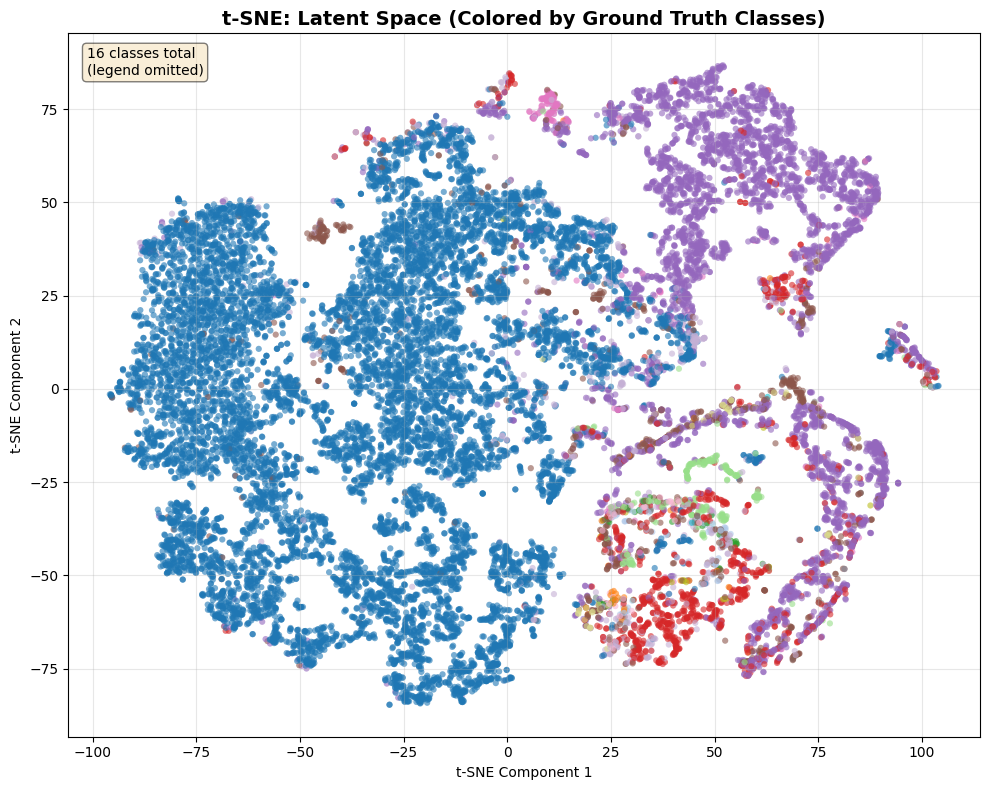


✓ Visualization complete. Latent dimensions: 128


In [ ]:
# 5.2 Latent Space Visualization (t-SNE and UMAP)
from sklearn.manifold import TSNE
import matplotlib.cm as cm
import matplotlib.patches as mpatches

# Prepare normalized latent space for visualization
scaler_viz = StandardScaler()
latent_normalized_viz = scaler_viz.fit_transform(latent_flat)

# Create color map for all classes
unique_classes = df['class'].unique()
n_classes = len(unique_classes)
colors_map = cm.get_cmap('tab20', n_classes)
class_to_color = {cls: colors_map(i) for i, cls in enumerate(unique_classes)}
colors_by_class = [class_to_color[cls] for cls in df['class']]

print("Computing dimensionality reductions for visualization...")

# ============================================================================
# t-SNE Embedding
# ============================================================================
print("  - Computing t-SNE (this may take 1-2 minutes)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)
tsne_embedding = tsne.fit_transform(latent_normalized_viz)
print("  ✓ t-SNE complete")

# ============================================================================
# UMAP Embedding (if available)
# ============================================================================
try:
    import umap
    print("  - Computing UMAP...")
    umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_embedding = umap_reducer.fit_transform(latent_normalized_viz)
    print("  ✓ UMAP complete")
    has_umap = True
except ImportError:
    print("  ⚠ UMAP not installed (pip install umap-learn). Skipping UMAP visualization.")
    has_umap = False

# ============================================================================
# Plotting
# ============================================================================
n_plots = 2 if has_umap else 1
fig, axes = plt.subplots(1, n_plots, figsize=(10*n_plots, 8))
if n_plots == 1:
    axes = [axes]

# Plot 1: t-SNE colored by ground truth
ax = axes[0]
scatter = ax.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], 
                     c=colors_by_class, s=20, alpha=0.6, edgecolors='none')
ax.set_title('t-SNE: Latent Space (Colored by Ground Truth Classes)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.grid(True, alpha=0.3)

# Create legend (limit to reasonable number of classes)
if n_classes <= 15:
    patches = [mpatches.Patch(color=class_to_color[cls], label=cls) 
               for cls in unique_classes]
    ax.legend(handles=patches, loc='best', ncol=2 if n_classes > 8 else 1, 
              fontsize=8, framealpha=0.9)
else:
    ax.text(0.02, 0.98, f'{n_classes} classes total\n(legend omitted)', 
            transform=ax.transAxes, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: UMAP colored by ground truth (if available)
if has_umap:
    ax = axes[1]
    scatter = ax.scatter(umap_embedding[:, 0], umap_embedding[:, 1], 
                         c=colors_by_class, s=20, alpha=0.6, edgecolors='none')
    ax.set_title('UMAP: Latent Space (Colored by Ground Truth Classes)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('UMAP Component 1')
    ax.set_ylabel('UMAP Component 2')
    ax.grid(True, alpha=0.3)
    
    if n_classes <= 15:
        patches = [mpatches.Patch(color=class_to_color[cls], label=cls) 
                   for cls in unique_classes]
        ax.legend(handles=patches, loc='best', ncol=2 if n_classes > 8 else 1, 
                  fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization complete. Latent dimensions: {latent_flat.shape[1]}")